In [1]:
import numpy as np
import wget
import astropy.io.fits as fits
import astropy.units as u
import healpy as hp
import pylab as pl 
from astropy.table import Table
from scipy.optimize import curve_fit

## 1. Read in offset-removed empirical data

In [2]:
nside = 256
npix = 12 * nside**2
with fits.open('../southern_data/fine_south_maps_nside'+str(nside)+'.fits') as hdul:
    table = hdul[1].data                                                                                                                                                          
    col_names = hdul[1].columns.names  # the original dict keys                                                                                                                 

    # Reconstruct as a dict
    maps = {name: table[name] for name in col_names}

## 2. Read in and substract Free-Free emission template

In [3]:
fstring="COM_CompMap_freefree-commander_0256_R2.00.fits"
try :
    print(f"reading {fstring} ")
    tmp=  hp.read_map(filename=f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )  
except FileNotFoundError: 
    filename = wget.download( f"http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=COM_CompMap_freefree-commander_0256_R2.00.fits" , out ="../lwa_data")
    tmp=  hp.read_map(f"../lwa_data/{fstring}" ,field= ['EM_ML', 'TEMP_ML']  )
 
planck_em = tmp[0]* u.cm**-6 *u.pc
planck_te = tmp [1]*u.K 

fstring = "EM_mean_std.fits"
try :
    print(f"reading {fstring} ")
    hust=  hp.read_map(filename=f"../lwa_data/{fstring}"   )  
except FileNotFoundError: 
    filename = wget.download( f"https://zenodo.org/records/10523170/files/EM_mean_std.fits" , out ="../lwa_data")
    hust =  hp.read_map(f"../lwa_data/{fstring}"    )
hust *= u.cm**-6 *u.pc

reading COM_CompMap_freefree-commander_0256_R2.00.fits 
reading EM_mean_std.fits 


In [4]:
Tff = lambda Te , nu,EM  : Te * (1.0 - np.exp(-tauff(Te,nu, EM ))) 
tauff = lambda Te,nu , EM : 0.05468 *   (Te.value )**-1.5 * (nu.value )**-2 *EM.value   *gff (Te,nu) 
Zi =1 
gff =lambda Te ,nu :  np.log (np.exp(1.0) +np.exp (5.960 -np.sqrt(3)/np.pi *np.log (Zi *nu.to(u.GHz).value *(Te/(1e4*u.K)  )**-1.5  )) )  
free ={} 
for fr in maps.keys() : 
    freq = float(fr) 
    tmp = Tff(Te=planck_te, nu=(freq*u.MHz).to(u.GHz), EM=hust)
    tmp = hp.ud_grade(tmp, nside)
    free[fr] = tmp * u.K  

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_2082/609357839.py:8: RuntimeWarning: invalid value encountered in log10
  hp.mollview(pl.log10(mapval), min=np.round(np.nanpercentile(pl.log10(mapval), 5), 1), max = np.round(np.nanpercentile(pl.log10(mapval), 95), 1), \


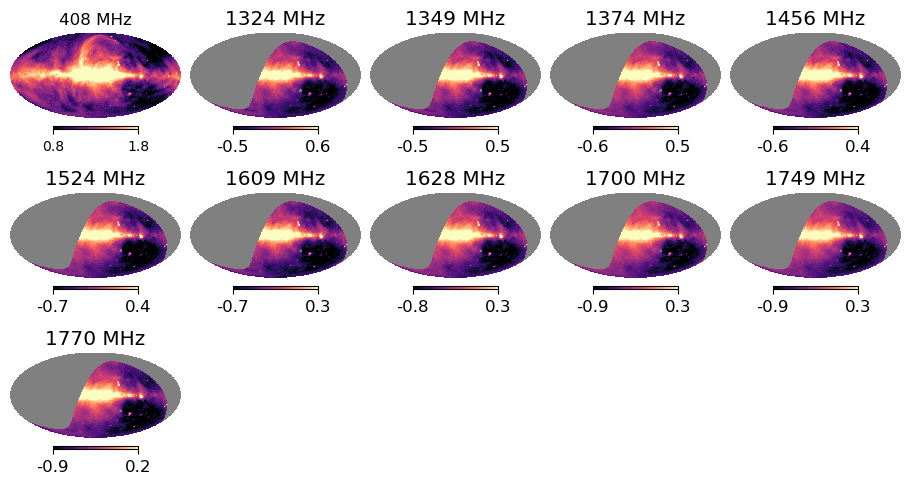

In [5]:
pl.figure(figsize=(9,8))
j=0
for fr,m in maps.items():

    freq = float(fr) 

    mapval = (m - free[fr].value) 
    hp.mollview(pl.log10(mapval), min=np.round(np.nanpercentile(pl.log10(mapval), 5), 1), max = np.round(np.nanpercentile(pl.log10(mapval), 95), 1), \
                title=f'{fr} MHz'  , cmap='magma', sub=(5,5,1+j), notext=True)
    fontsize = 12
    import matplotlib
    matplotlib.rcParams.update({'font.size':fontsize})
    f = matplotlib.pyplot.gcf().get_children()
    HpxAx = f[1]
    CbAx = f[2]
    coord_text_obj = HpxAx.get_children()[7]
    coord_text_obj.set_fontsize(fontsize)
    
    j+=1

#pl.savefig('freqmaps_north.png', format='png', bbox_inches='tight')
pl.show() 

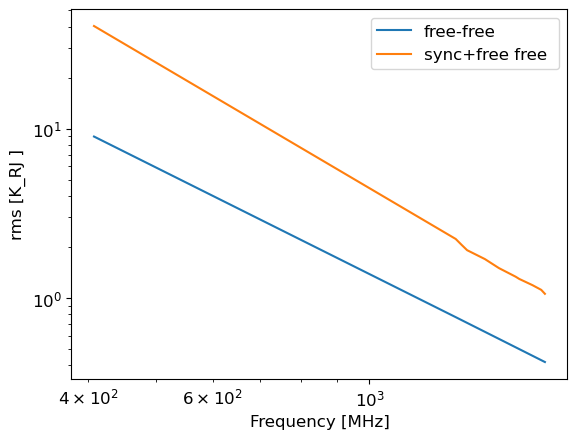

In [6]:
freqs = np.array([float(fr) for fr in maps.keys()])
rmsf = np.array([np.nanstd(f.value) for f in free.values()]) 
rmsm = np.array([np.nanstd(m) for fr,m in maps.items()]) 
pl.loglog(freqs, rmsf  ,label='free-free')
pl.loglog(freqs, rmsm  , label='sync+free free ')

pl.legend()
pl.xlabel('Frequency [MHz]')
pl.ylabel('rms [K_RJ ]')  
pl.show() 

## 3. Read in error maps and perform LSQ fit

In [7]:
errs = np.load('../southern_data/fine_south_errors_dict.npz')
thermerr = {}
for key in errs.files:
    thermerr[float(key)] = np.random.normal(loc=0.0, scale=errs[key], size=npix)

# fitted offset errors
file = open("../outputs/offset_coarse_south.txt")
oldk = []
c_off = []
c_err  = []

for line in file:
    values = line.strip().split()
    oldk.append(float(values[0]))
    c_off.append(float(values[1]))
    c_err.append(float(values[2]))

offs = np.asarray(c_off)
off_errs = np.asarray(c_err)
oldk = np.asarray(oldk)

#Calibration erros from the literature
mapserr = {}
mapserr[408] = 0.10
mapserr[1324] = 0.1
mapserr[1349] = 0.1 
mapserr[1374] = 0.1
mapserr[1456] = 0.1
mapserr[1524] = 0.1
mapserr[1609] = 0.1
mapserr[1628] = 0.1
mapserr[1700] = 0.1
mapserr[1749] = 0.1
mapserr[1770] = 0.1

common_footprint = hp.read_map("../outputs/common_footprint_southern.fits").astype(bool)

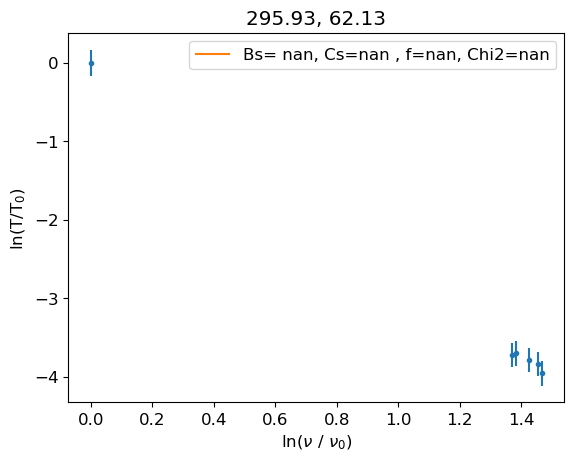

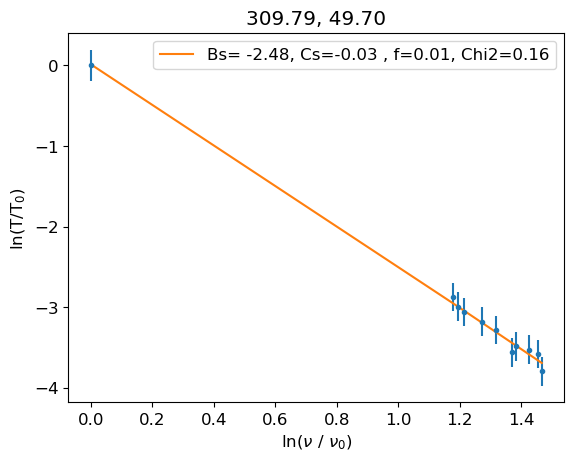

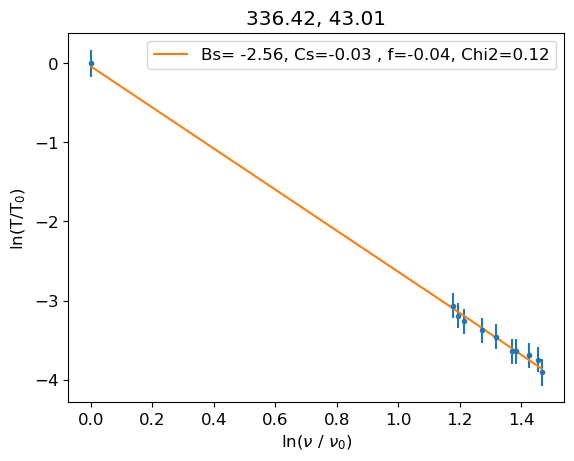

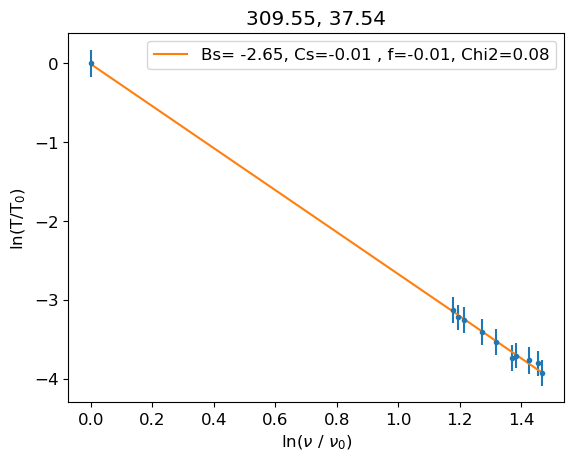

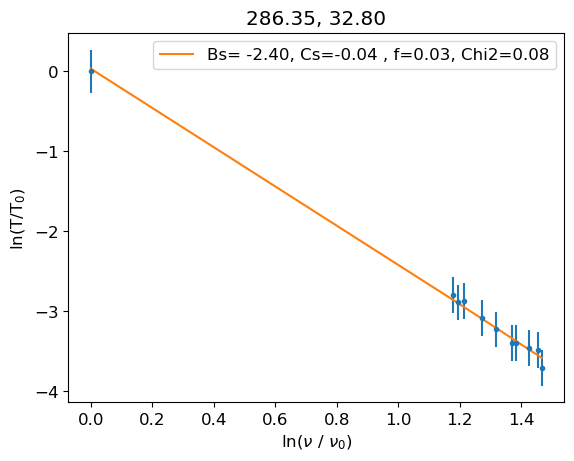

In [8]:
def fitting_beta_curvature(X, beta, cs, const):
    return beta * X + cs * X * X + const

def process_pixel(ipix, return_errors=False):
    ifreq = np.argmin(np.abs(freqs - 45))
    pixvals = np.array([(m[ipix] - free[k][ipix].value) for k, m in maps.items()])
    nans = np.isnan(pixvals)
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq])
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        freq = float(k) 
        errm = mapserr[freq]
        if freq != 408:
            theval = np.where(oldk == freq)[0][0]
            pix_errs[cc] = np.sqrt((errm * m[ipix])**2 + off_errs[theval]**2 + thermerr[freq][ipix]**2)
        else: 
            pix_errs[cc] = np.sqrt((errm * m[ipix])**2 + 1.3**2 +thermerr[freq][ipix]**2)
        cc += 1
    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    lsmaps= hp.read_map('../outputs/bfit_maps_south_coarse.fits', field=None )
    oldbs =lsmaps[0]
    oldcs = lsmaps[1]

    p0 = np.array([-3, -0.1, 1])
    ret = np.full(p0.size + 2, np.nan)
    ret[0] = ipix
    errs = np.full(p0.size, np.nan)
    pcov = np.zeros((3, 3)) + np.nan
    if nans.sum():
        return (ret, errs) 
    try:
        p0 = np.array([oldbs[ipix], 
                   oldcs[ipix],
                    1.0])
        lowb = oldbs[ipix] - 0.05 * abs(oldbs[ipix])
        hib = oldbs[ipix] + 0.05 * abs(oldbs[ipix])
        lowc = oldcs[ipix] - 0.05 *abs(oldcs[ipix])
        hic = oldcs[ipix] + 0.05 * abs(oldcs[ipix])
        popt, pcov = curve_fit(fitting_beta_curvature, xdat, ydat, 
                               sigma=logyerr,  p0=p0, bounds = ((lowb, lowc, -100.), (hib, hic, 100.))) 
        ret[-1] = np.sum(((ydat - fitting_beta_curvature(xdat, *popt)) / logyerr) ** 2) / (xdat.size - p0.size)
        ret[1:-1] = popt
        errs = np.sqrt(np.diag(pcov))
        return ret, errs 
    except Exception:
        return ret, errs 

pixel_select = np.arange(npix)[common_footprint]
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)

error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)

jj = 0
for ipix in pixel_select[::1000]:
    # Use return_errors=True for error estimation, False for covariance
    fitted_params, error_params = process_pixel(ipix, return_errors=True)
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] = fitted_params[3]
    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = error_params[0]
    error_csmap[ipix] = error_params[1]
    error_fmap[ipix] = error_params[2]
    pixvals = np.array([ (m[ipix] - free[k][ipix ] .value)  for k, m in maps.items() ])
    nans = np.isnan(pixvals)
    ifreq = np.argmin(np.abs(freqs - 408))
    ydat = pl.log(pixvals / pixvals[ifreq])
    xdat = pl.log(freqs / freqs[ifreq] )

    #data errors are calibration errors plus offset errors
    pix_errs = np.zeros_like(ydat)
    cc = 0
    for k, m in maps.items():
        freq = float(k)
        errm = mapserr[freq]
        if freq != 408:
            theval = np.where(oldk == freq)[0][0]
            pix_errs[cc] = np.sqrt((errm * m[ipix])**2 + off_errs[theval]**2 + thermerr[freq][ipix]**2)
        else: 
            pix_errs[cc] = np.sqrt((errm * m[ipix])**2 + 1.3**2 +thermerr[freq][ipix]**2)
        cc += 1

    logyerr = np.sqrt((pix_errs[0] /pixvals[0])**2 + (pix_errs / pixvals)**2)

    if jj%10==0:
        pl.figure() 
        lon,lat =hp.pix2ang(ipix=ipix, nside=nside, lonlat=True) 
        pl.title( f"{lon:.2f}, {lat:.2f}" )
        pl.errorbar ( xdat ,  ydat ,
                     yerr= logyerr  ,
                        fmt='.' )
         
        pl.plot( xdat ,  fitting_beta_curvature( xdat , *fitted_params[1:-1] ),  
                label =f'Bs= {fitted_params[1]:.2f}, Cs={fitted_params[2]:.2f} , f={fitted_params[3]:.2f}, Chi2={fitted_params[-1]:.2f}' ) 
                #, Bf={fitted_params[4]:.2f}, 

        #pl.semilogx() 
        #pl.loglog() 
        pl.legend()
        pl.xlabel(r"ln($\nu$ / $\nu_{0}$)")
        pl.ylabel(r"ln(T/T$_{0}$)") 
    jj+=1 
    if jj== 50: break

In [9]:
from concurrent.futures import ThreadPoolExecutor
import tqdm

    
# Initialize shared arrays
betamap = np.full(hp.nside2npix(nside), np.nan)
fmap = np.full(hp.nside2npix(nside), np.nan)
csmap = np.full(hp.nside2npix(nside), np.nan)
betafmap = np.full(hp.nside2npix(nside), np.nan)
chisquare_map = np.full(hp.nside2npix(nside), np.nan)
error_betamap = np.full(hp.nside2npix(nside), np.nan)
error_csmap = np.full(hp.nside2npix(nside), np.nan)
error_fmap = np.full(hp.nside2npix(nside), np.nan)


# Use ThreadPoolExecutor for parallel processing
with ThreadPoolExecutor() as executor:
    results = list(tqdm.tqdm(executor.map(process_pixel, pixel_select), total=len(pixel_select)))

for fitted_params, errs  in results:
    ipix = int(fitted_params[0])  # Ensure ipix is an integer
    betamap[ipix] = fitted_params[1]
    csmap[ipix] = fitted_params[2]
    fmap[ipix] =   fitted_params[3]

    chisquare_map[ipix] = fitted_params[-1]
    error_betamap[ipix] = errs[0]
    error_csmap[ipix] = errs[1]
    error_fmap[ipix] = errs[2]

    


 35%|███▌      | 133884/381326 [17:40<33:02, 124.82it/s] /var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_2082/2289915371.py:8: RuntimeWarning: invalid value encountered in log
  ydat = pl.log(pixvals / pixvals[ifreq])
100%|██████████| 381326/381326 [49:54<00:00, 127.33it/s] 


/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_2082/3091120307.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


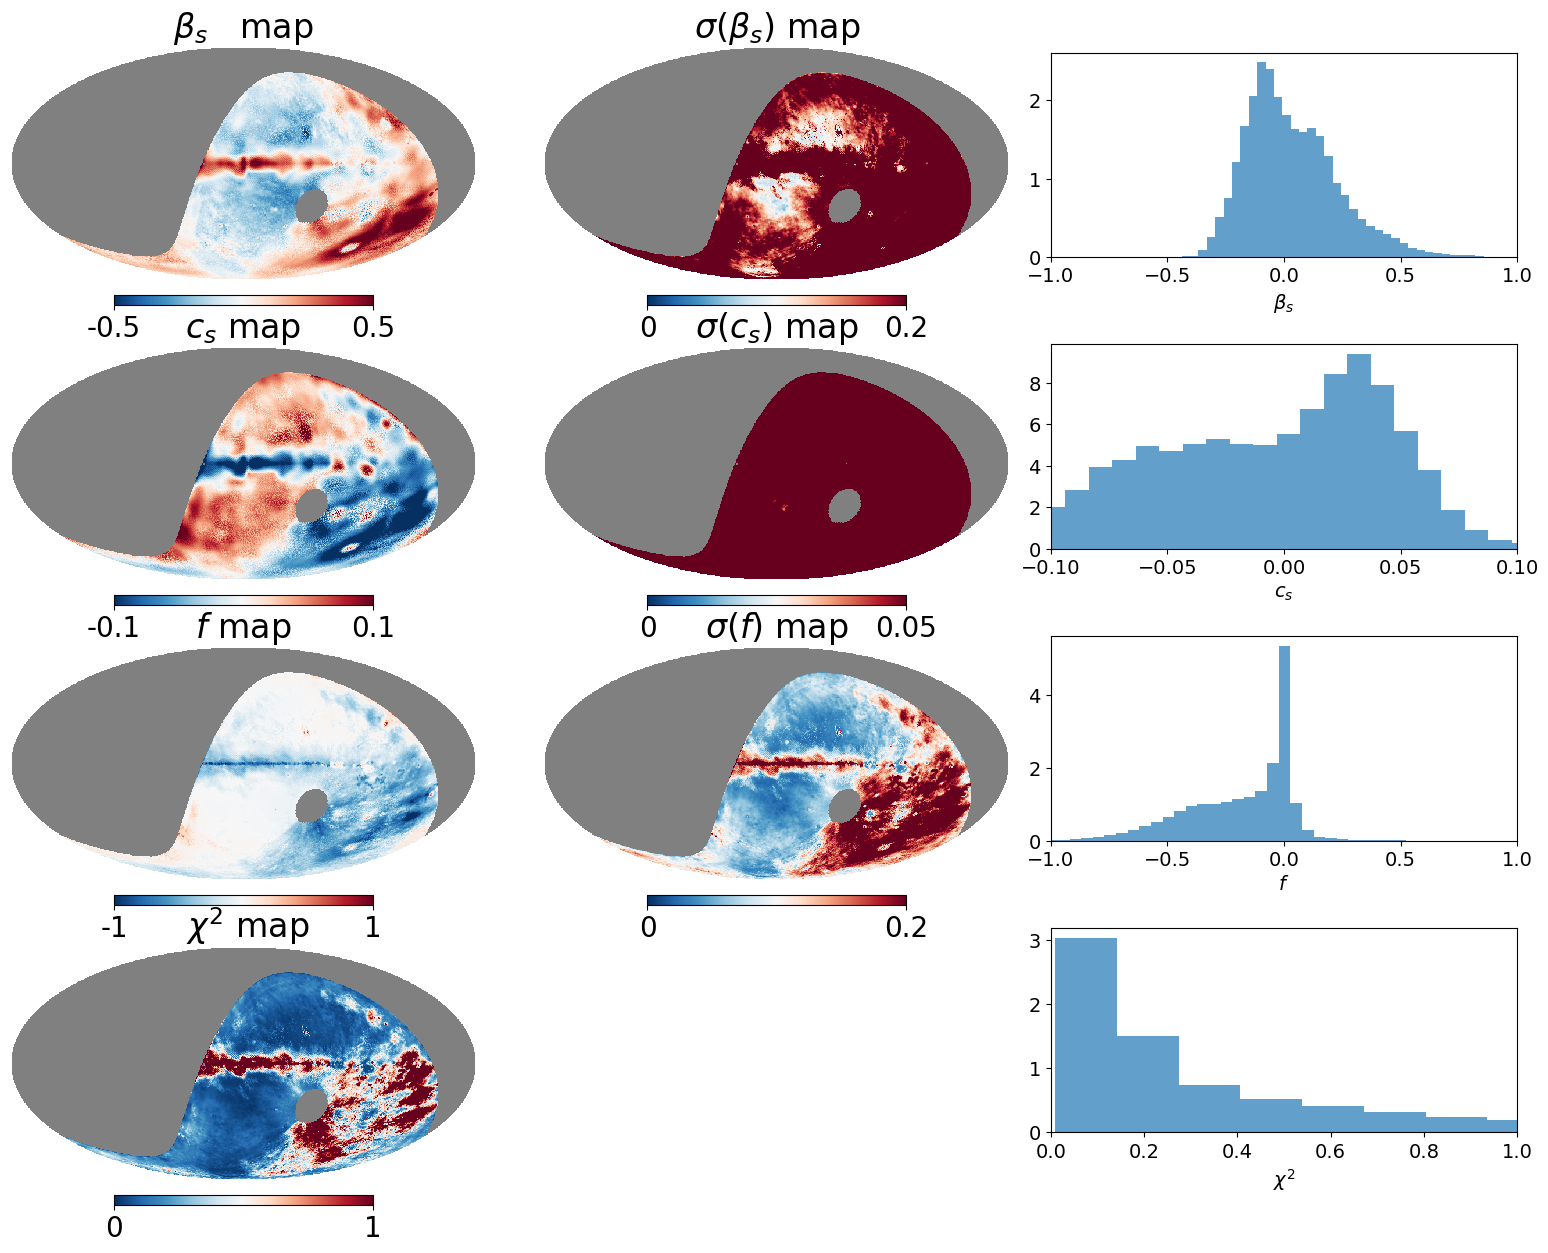

/var/folders/2g/628b43qx6hl0gt4rypm9clz00000gn/T/ipykernel_2082/3091120307.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pl.tight_layout()


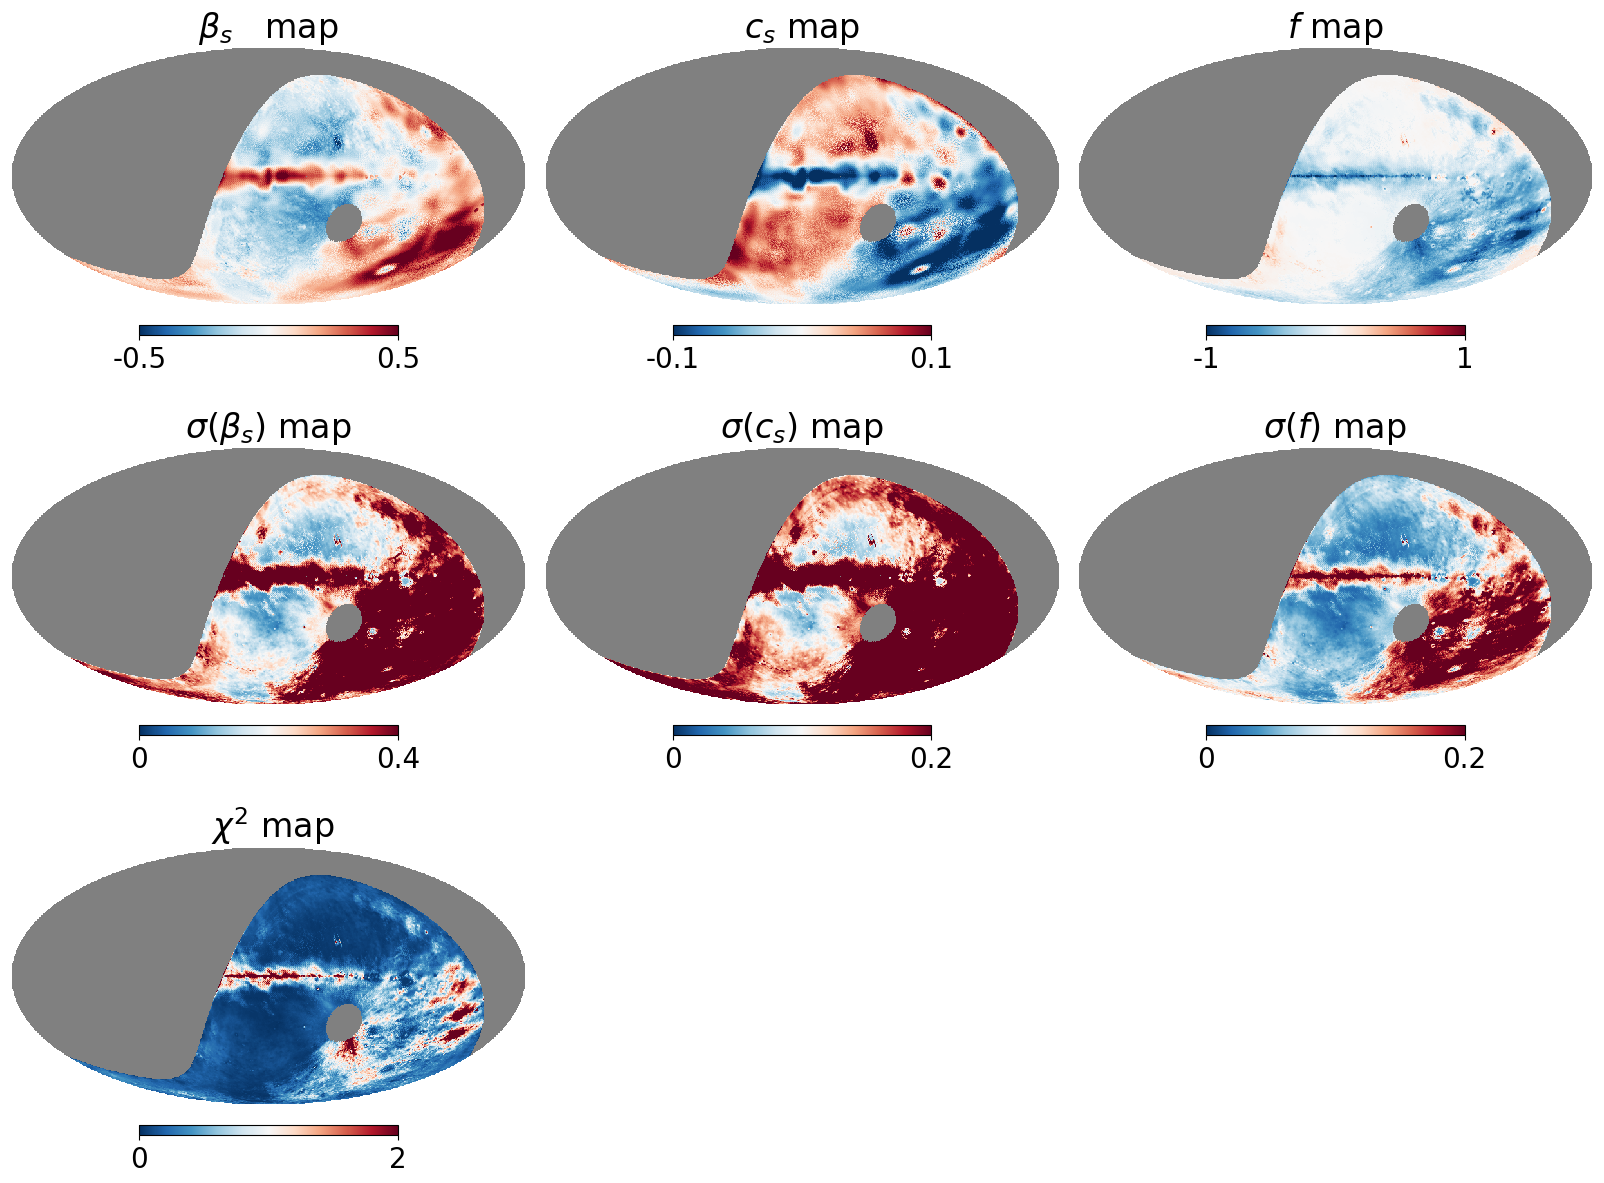

In [10]:
betamap = betamap - np.nanmedian(betamap)
csmap = csmap - np.nanmedian(csmap)

fig, axes = pl.subplots(4, 3, figsize=(16, 12))
fontsize = 20
import matplotlib
matplotlib.rcParams.update({'font.size':fontsize})

# 1st row: betamap
hp.mollview(betamap, sub=(4, 3, 1), min=-0.5, max=0.5,  cmap='RdBu_r',  notext=True,  title=r'$\beta_s$   map' )
f = matplotlib.pyplot.gcf().get_children()
HpxAx = f[1]
CbAx = f[2]

coord_text_obj = HpxAx.get_children()[6]
coord_text_obj.set_fontsize(fontsize)

unit_text_obj = CbAx.get_children()[7]
unit_text_obj.set_fontsize(fontsize)
hp.mollview(error_betamap, sub=(4, 3, 2), min=0, max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(\beta_s)$ map')
axes[0, 2].hist(betamap[~np.isnan(betamap)], bins=50, density=True, color='C0', alpha=0.7)
axes[0, 2].set_xlabel(r'$\beta_s$', fontsize=14)
#axes[0, 2].set_ylabel('Density')
axes[0, 2].set_xlim( [-1.0, 1.0])
axes[0, 2].tick_params(axis='both', which='major', labelsize=14)
axes[0, 2].tick_params(axis='both', which='minor', labelsize=14)

# 2nd row: csmap

hp.mollview(csmap, sub=(4, 3, 4), min=-0.1, max=0.1,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$c_s$ map')

hp.mollview(error_csmap, sub=(4, 3, 5), min=0, max=0.05,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(c_s)$ map')

axes[1, 2].hist(csmap[~np.isnan(csmap)], bins=50, density=True, color='C0', alpha=0.7)
axes[1, 2].set_xlabel(r'$c_s$', fontsize=14)
axes[1, 2].set_xlim( [-.1, .1 ])
axes[1, 2].tick_params(axis='both', which='major', labelsize=14)
axes[1, 2].tick_params(axis='both', which='minor', labelsize=14)

# 3rd row: fmap
hp.mollview(fmap, sub=(4, 3, 7),  cmap='RdBu_r',min=-1,max=1,  notext=True, fig=fig, title=r'$f$ map')
hp.mollview(error_fmap, sub=(4, 3, 8), min=0, max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(f)$ map')

axes[2, 2].hist(fmap[~np.isnan(fmap)], bins=50, density=True, color='C0', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[2, 2].set_xlabel(r'$f$', fontsize=14)
axes[2, 2].set_xlim( [-1, 1 ])
axes[2, 2].tick_params(axis='both', which='major', labelsize=14)
axes[2, 2].tick_params(axis='both', which='minor', labelsize=14)

hp.mollview(chisquare_map  , sub=(4,3,10) ,  min=0 ,max=1, cmap='RdBu_r',notext=True , title=' $\chi^2$ map' ) 
axes[3, 2].hist(chisquare_map[~np.isnan(chisquare_map)], bins=50, density=True, color='C0', alpha=0.7)
#axes[2, 2].set_ylabel('Density')
axes[3, 2].set_xlabel( r'$ \chi^2$', fontsize=14)
axes[3, 2].set_xlim( [0,1])
axes[3, 2].tick_params(axis='both', which='major', labelsize=14)
axes[3, 2].tick_params(axis='both', which='minor', labelsize=14)
# Remove empty axes from the figure
for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            fig.delaxes(ax)
pl.tight_layout()
pl.show()

fig, axes = pl.subplots(4, 3, figsize=(16, 12))
fontsize = 20
matplotlib.rcParams.update({'font.size':fontsize})

# 1st row: betamap
hp.mollview(betamap, sub=(3, 3, 1), min=-0.5, max=0.5,  cmap='RdBu_r', notext=True,  title=r'$\beta_s$   map' )
f = matplotlib.pyplot.gcf().get_children()
HpxAx = f[1]
CbAx = f[2]

coord_text_obj = HpxAx.get_children()[6]
coord_text_obj.set_fontsize(fontsize)

unit_text_obj = CbAx.get_children()[7]
unit_text_obj.set_fontsize(fontsize)

hp.mollview(csmap, sub=(3, 3, 2), min=-0.1, max=0.1,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$c_s$ map')
hp.mollview(fmap, sub=(3, 3, 3),  cmap='RdBu_r',min=-1,max=1,  notext=True, fig=fig, title=r'$f$ map')


hp.mollview(error_betamap, sub=(3, 3, 4), min=0, max=0.4,  cmap='RdBu_r', notext=True, fig=fig, title=r'$\sigma(\beta_s)$ map')
hp.mollview(error_csmap, sub=(3, 3, 5), min=0, max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(c_s)$ map')
hp.mollview(error_fmap, sub=(3, 3, 6), min=0, max=0.2,  cmap='RdBu_r',  notext=True, fig=fig, title=r'$\sigma(f)$ map')


hp.mollview(chisquare_map   , sub=(3,3,7) ,  min=0 ,max=2, cmap='RdBu_r',notext=True , title=' $\chi^2$ map' ) 


# Remove empty axes from the figure
for ax_row in axes:
    for ax in ax_row:
        if not ax.has_data():
            fig.delaxes(ax)
pl.tight_layout()
#pl.savefig('res_1deg_south.png', format='png', bbox_inches='tight')
pl.show()

In [11]:
# Save all maps into a single HEALPix FITS file
hp.write_map(
    "../outputs/bfit_maps_south_fine.fits",
    [betamap, csmap, fmap, error_betamap , error_csmap, error_fmap , chisquare_map ],
    column_names=["BETAMAP", "CSMAP", "FMAP","BETAMAP_ERR", "CSMAP_ERR", "FMAP_ERR" ,"CHISQUARE"  ],
    overwrite=True,
    dtype=np.float32
)
